In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%pip install numpy
%pip install pandas
%pip install pytest
%pip install jinja2

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrad

## Revenue statistics

In [17]:
from src.route import Route
import pandas

routes_data = {
    'Kampala-Ntinda': {'fare':2000, 'passenger-count':[35, 40, 42, 50, 55, 60, 48, 52, 47, 45]},
    'Kampala-Entebbe': {'fare':5000, 'passenger-count':[60, 58, 65, 70, 72, 80, 75, 68, 66, 64]},
    'Kampala-Mukono': {'fare':3000, 'passenger-count':[45, 47, 50, 49, 55, 62, 58, 53, 51, 50]},
         }

results = []
for r_name, r_data in routes_data.items():
    route_obj= Route(r_name, r_data['passenger-count'], r_data['fare'])
    results.append(
        {"route":r_name,
         'daily_revenues':route_obj.daily_revenue(),
         'total_revenue':route_obj.total_revenue(),
         "mean":route_obj.mean(),
         "variance":route_obj.variance(),
         "std":route_obj.std()

        })


## Daily revenue

In [16]:
pandas.set_option("display.width", None)
pandas.set_option("display.max_columns", None)

daily_table = pandas.DataFrame({r["route"]: r["daily_revenues"] for r in results}).T
daily_table.columns = [f"Day {i + 1}" for i in range(daily_table.shape[1])]
daily_table.index.name = "route"

print(daily_table.to_string())

                  Day 1   Day 2   Day 3   Day 4   Day 5   Day 6   Day 7   Day 8   Day 9  Day 10
route                                                                                          
Kampala-Ntinda    70000   80000   84000  100000  110000  120000   96000  104000   94000   90000
Kampala-Entebbe  300000  290000  325000  350000  360000  400000  375000  340000  330000  320000
Kampala-Mukono   135000  141000  150000  147000  165000  186000  174000  159000  153000  150000


## Revenue Statistics

In [12]:
stats_table = pandas.DataFrame(results).drop(columns="daily_revenues").set_index("route")
print(stats_table.round(2))

                 total_revenue    mean      variance       std
route                                                         
Kampala-Ntinda          948000   94800  2.170667e+08  14733.18
Kampala-Entebbe        3390000  339000  1.126667e+09  33565.86
Kampala-Mukono         1560000  156000  2.380000e+08  15427.25


## Solve the linear system

In [ ]:
import numpy
from src.matrix_equation import MatrixEquation

""" Equation formula
Qd = 120 - 0.02P    or  Q + 0.02P = 120
Qs = 10 + 0.03P     or  Qs - 0.03P = 10
"""

coefficients = numpy.array([[1,  0.02], [1, -0.03]])
ntinda = MatrixEquation(coefficients)

Q_eq, P_eq = ntinda.solve(120, 10)
print(f"Equilibrium fare: UGX {P_eq:,.0f}")                          
print(f"Equilibrium quantity: {Q_eq:.0f} passengers per trip-hour") 

# Compare with the current fare
P_now = 2000
Qd = 120 - 0.02 * P_now     # 80
Qs = 10 + 0.03 * P_now      # 70
print(f"At UGX {P_now:,}: demand {Qd:.0f}, supply {Qs:.0f}, shortage {Qd - Qs:.0f}")

Equilibrium fare: UGX 2,200
Equilibrium quantity: 76 passengers per trip-hour
At UGX 2,000: demand 80, supply 70, shortage 10


## Rolling origin back testing

In [25]:
import numpy
import pandas
from src.moving_average import MovingAverage
from src.exponential_smoothing import ExponentialSmoothing
from src.linear import Linear

def backtest(make_model, series, first_day=4, last_day=10) -> float:
    """Walk-forward MAE: for each day, fit on all earlier days and predict that day."""
    s = numpy.asarray(series, dtype=float)
    errors = []
    for day in range(first_day, last_day + 1):
        train = s[:day - 1]                          # days 1 .. day-1
        forecast = make_model().fit(train).predict(1)[0]
        errors.append(abs(s[day - 1] - forecast))
    return float(numpy.mean(errors))

alphas = numpy.round(numpy.arange(0.05, 1.0001, 0.05), 2)   # 0.05, 0.10, ..., 1.00

rows = []
for name, data in routes_data.items():
    y = data["passenger-count"]

    # grid search: backtest every alpha and keep the one with the lowest MAE
    ses_mae = {a: backtest(lambda a=a: ExponentialSmoothing(a), y) for a in alphas}
    best_alpha = min(ses_mae, key=ses_mae.get)

    rows.append({
        "route": name,
        "MovingAverage(3)": backtest(lambda: MovingAverage(3), y),
        "Linear": backtest(Linear, y),
        "SES (α=0.5)": ses_mae[0.5],
        "SES (tuned)": ses_mae[best_alpha],
        "best α": best_alpha,
    })

mae_table = pandas.DataFrame(rows).set_index("route")
print(mae_table.round(2).to_string())

                 MovingAverage(3)  Linear  SES (α=0.5)  SES (tuned)  best α
route                                                                      
Kampala-Ntinda               7.52    7.87         6.72         5.86     1.0
Kampala-Entebbe              7.19    7.71         6.04         4.43     1.0
Kampala-Mukono               5.33    6.39         4.38         3.71     1.0


## Forecase day 11 with best model

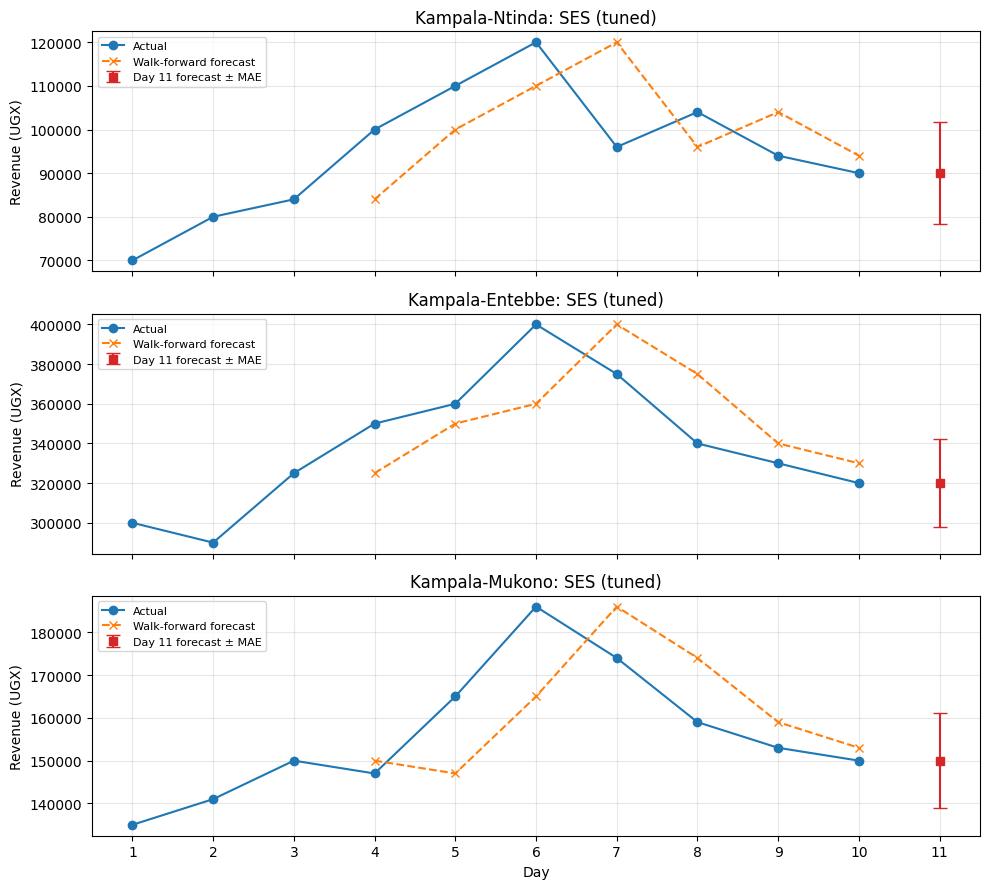

                       model  day 11 passengers  day 11 revenue (UGX)  ± MAE (UGX)
route                                                                             
Kampala-Ntinda   SES (tuned)               45.0               90000.0      11714.0
Kampala-Entebbe  SES (tuned)               64.0              320000.0      22143.0
Kampala-Mukono   SES (tuned)               50.0              150000.0      11143.0


In [26]:
import matplotlib.pyplot as plt

def best_model(route: str):
    """Return (name, model factory, MAE) for the route's lowest-MAE model."""
    r = mae_table.loc[route]
    options = {
        "MovingAverage(3)": lambda: MovingAverage(3),
        "Linear": lambda: Linear(),
        "SES (tuned)": lambda: ExponentialSmoothing(r["best α"]),
    }
    name = min(options, key=lambda k: r[k])
    return name, options[name], r[name]

forecast_rows = []
fig, axes = plt.subplots(len(routes_data), 1, figsize=(10, 9), sharex=True)

for ax, (route, data) in zip(axes, routes_data.items()):
    counts = numpy.asarray(data["passenger-count"], dtype=float)
    fare = data["fare"]
    name, make_model, mae = best_model(route)

    days = numpy.arange(1, len(counts) + 1)
    backtest_days = numpy.arange(4, len(counts) + 1)
    backtest_revenue = [make_model().fit(counts[:d - 1]).predict(1)[0] * fare for d in backtest_days]
    day11_revenue = make_model().fit(counts).predict(1)[0] * fare     # trained on all 10 days

    forecast_rows.append({
        "route": route,
        "model": name,
        "day 11 passengers": day11_revenue / fare,
        "day 11 revenue (UGX)": day11_revenue,
        "± MAE (UGX)": mae * fare,
    })

    ax.plot(days, counts * fare, marker="o", label="Actual")
    ax.plot(backtest_days, backtest_revenue, marker="x", linestyle="--", label="Walk-forward forecast")
    ax.errorbar([11], [day11_revenue], yerr=[mae * fare], fmt="s", color="tab:red",
                capsize=5, label="Day 11 forecast ± MAE")
    ax.set_title(f"{route}: {name}")
    ax.set_ylabel("Revenue (UGX)")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left", fontsize=8)

axes[-1].set_xticks(range(1, 12))
axes[-1].set_xlabel("Day")
fig.tight_layout()
plt.show()

print(pandas.DataFrame(forecast_rows).set_index("route").round(0).to_string())

## Fleet planning

In [27]:
import math


#8 trip per day, 14 seat a trip, 112 passengers per vehicle per day
capacity = 8 * 14         

fleet_rows = []
for row in forecast_rows:
    #buffer of 15%, 0.15
    demand = row["day 11 passengers"] * (1 + 0.15)
    vehicles = math.ceil(demand / capacity)
    fleet_rows.append({
        "route": row["route"],
        "forecast passengers": row["day 11 passengers"],
        "with 15% buffer": round(demand, 1),
        "vehicles": vehicles,
        "seats offered": vehicles * capacity,
        "utilisation": f"{row['day 11 passengers'] / (vehicles * capacity):.0%}",
    })

print(pandas.DataFrame(fleet_rows).set_index("route").to_string())

                 forecast passengers  with 15% buffer  vehicles  seats offered utilisation
route                                                                                     
Kampala-Ntinda                  45.0             51.7         1            112         40%
Kampala-Entebbe                 64.0             73.6         1            112         57%
Kampala-Mukono                  50.0             57.5         1            112         45%


## 60 days data simulation

In [ ]:
import numpy
import pandas
import matplotlib.pyplot as plt
from src.seasonal_naive import SeasonalNaive

n_days = 60
weekly = numpy.array([1.00, 0.95, 1.00, 1.05, 1.35, 1.10, 0.60])   # Fri busiest, Sun quietest

rng = numpy.random.default_rng(42)                   # fixed seed, same data every run
simulated = {}
for route, data in routes_data.items():
    base = numpy.mean(data["passenger-count"])       # each route keeps its own typical level
    pattern = weekly[numpy.arange(n_days) % 7]         # day 1 is a Monday
    noise = rng.normal(0, 0.05 * base, n_days)         # random day-to-day variation
    simulated[route] = numpy.round(base * pattern + noise).clip(min=0)

first, last = 15, n_days
rows = []
for route, y in simulated.items():
    ses = {a: backtest(lambda a=a: ExponentialSmoothing(a), y, first, last) for a in alphas}
    best = min(ses, key=ses.get)
    rows.append({
        "route": route,
        "SeasonalNaive(7)": backtest(lambda: SeasonalNaive(7), y, first, last),
        "MovingAverage(3)": backtest(lambda: MovingAverage(3), y, first, last),
        "SES (tuned)": ses[best],
        "best α": best,
        "Linear": backtest(Linear, y, first, last),
    })

season_table = pandas.DataFrame(rows).set_index("route")
print(season_table.round(2).to_string())

                 SeasonalNaive(7)  MovingAverage(3)  SES (tuned)  best α  Linear
route                                                                           
Kampala-Ntinda               2.22              7.94         6.27    0.05    6.40
Kampala-Entebbe              2.98             11.32         9.01    0.10    9.15
Kampala-Mukono               2.61              9.31         7.50    0.05    7.74
